### Q1: Linear Regression - Single Variable:

Importing all the required libraries

In [82]:
# performing linear algebra
import numpy as np

# data processing
import pandas as pd

# visualisation
import matplotlib.pyplot as plt
import math

Importing the dataset and removing NULL cells.

In [85]:
df = pd.read_csv("cancer_dataset.csv")
df = df.dropna()
df

,ID,Outcome,Time,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,...,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension,Tumor Size,Lymph Node Status
0,119513,N,31,18.02,27.60,117.50,1013.0,0.09489,0.10360,0.10860,...,139.70,1436.0,0.11950,0.1926,0.3140,0.11700,0.2677,0.08113,5.0,5.0
1,8423,N,61,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,...,184.60,2019.0,0.16220,0.6656,0.7119,0.26540,0.4601,0.11890,3.0,2.0
2,842517,N,116,21.37,17.44,137.50,1373.0,0.08836,0.11890,0.12550,...,159.10,1949.0,0.11880,0.3449,0.3414,0.20320,0.4334,0.09067,2.5,0.0
3,843483,N,123,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,...,98.87,567.7,0.20980,0.8663,0.6869,0.25750,0.6638,0.17300,2.0,0.0
4,843584,R,27,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,...,152.20,1575.0,0.13740,0.2050,0.4000,0.16250,0.2364,0.07678,3.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,9411300,N,3,14.72,25.26,99.28,657.5,0.11740,0.21120,0.17290,...,111.60,814.8,0.14640,0.5352,0.5655,0.19740,0.3778,0.11320,1.7,21.0
193,942640,N,10,22.52,21.92,146.90,1597.0,0.07592,0.09162,0.06862,...,162.10,1902.0,0.08191,0.1319,0.1056,0.09378,0.2061,0.05788,6.0,2.0
194,943471,N,8,15.44,31.18,101.00,740.4,0.09399,0.10620,0.13750,...,112.60,929.0,0.12720,0.2362,0.2975,0.12860,0.2914,0.08024,1.5,0.0
195,94547,N,12,17.17,29.19,110.00,915.3,0.08952,0.06655,0.06583,...,132.50,1295.0,0.12610,0.1572,0.2141,0.09520,0.3362,0.06033,3.7,0.0


In [86]:
df.shape[0]

194

Splitting the data into Training & Test

In [87]:
def df_split(df,test_split):
    array_lenght = len(df)
    test_num = int(array_lenght * test_split)
    
    x_train = df[:-test_num]["Mean Texture"]
    y_train = df[:-test_num]["Tumor Size"]
    x_test = df[-test_num:]["Mean Texture"]
    y_test = df[-test_num:]["Tumor Size"]
    
    return x_train, y_train, x_test, y_test

In [9]:
x_train, y_train, x_test, y_test = df_split(df,0.2)

x_train, y_train, x_test, y_test 

(0      27.60
 1      10.38
 2      17.44
 3      20.38
 4      14.34
        ...  
 154    19.51
 155    18.82
 156    20.20
 157    20.56
 158    17.52
 Name: Mean Texture, Length: 156, dtype: float64,
 0      5.0
 1      3.0
 2      2.5
 3      2.0
 4      3.5
       ... 
 154    1.0
 155    7.0
 156    2.5
 157    3.5
 158    3.0
 Name: Tumor Size, Length: 156, dtype: float64,
 159    21.24
 160    24.49
 161    18.74
 162    23.95
 163    19.07
 164    20.58
 165    20.26
 166    21.60
 167    31.39
 168    30.62
 169    25.09
 170    22.39
 171    28.25
 172    28.08
 173    23.83
 174    26.17
 175    30.64
 176    25.28
 177    30.99
 178    25.48
 179    26.79
 180    17.10
 181    20.88
 182    24.51
 183    27.42
 184    23.96
 185    24.70
 186    33.87
 187    29.95
 188    30.98
 189    20.46
 190    27.41
 191    27.18
 192    25.26
 193    21.92
 194    31.18
 195    29.19
 197    28.13
 Name: Mean Texture, dtype: float64,
 159     5.5
 160     1.0
 161     3.0
 162    

Cost Function

In [10]:
def cost_function_single(m,b,xi,yi): #Loss Function/Mean Square Error
    total_error = 0
    for i in range (len(xi)): 
        x = xi.iloc[i]
        y = yi.iloc[i]
        total_error += ((m * x + b) - y)**2
    return total_error/(2*len(xi))

Gradient Descent

In [11]:
def gradiant_descent_single (m_now ,b_now, xi,yi, l):
    m_gradiant = 0
    b_gradiant = 0
    
    n = len(xi)
    
    for i in range(n):
        x = xi.iloc[i]
        y = yi.iloc[i]
    
        m_gradiant += -(1/n) * x * (y - (m_now * x + b_now))
        b_gradiant += -(1/n) * (y - (m_now * x + b_now))
        
    m = m_now - m_gradiant * l #Coefficient/Theta_1/Weights
    b = b_now - b_gradiant * l #Intercepts/Theta_0/biases
    
    return m,b

Calling the Cost & GD functions

In [12]:
m = 1
b = 1 
itr = 1000
l = 0.0007
cost = []

for i in range (itr):
    m, b = gradiant_descent_single(m,b,x_train,y_train,l)
    cost.append(cost_function_single (m,b,x_test,y_test))
print("The value of m is: ",m,"\nThe value of b is: ",b)
print("\nThe minimum cost of the model is: ",min(cost))

The value of m is:  0.08750787925525076 
The value of b is:  0.9885482292593702

The minimum cost of the model is:  2.1229263984568165


Graph depicting the Testing Data and the Predicted data:

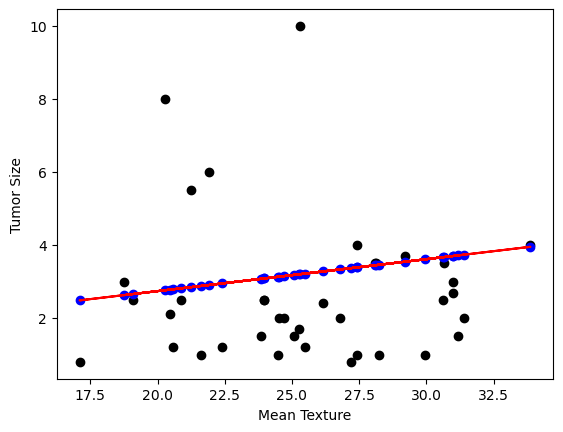

In [13]:
plt.scatter (x_test, y_test,color = "black")
plt.scatter (x_test, [m * x + b for x in x_test],color = "blue")
defined_range = range(int(min(x_test)),int(max(x_test)))
plt.plot (x_test, [m * x + b for x in x_test], color = "red")
plt.xlabel ("Mean Texture")
plt.ylabel ("Tumor Size")
plt.show()

Graph depecting the Cost Function for Testing Data

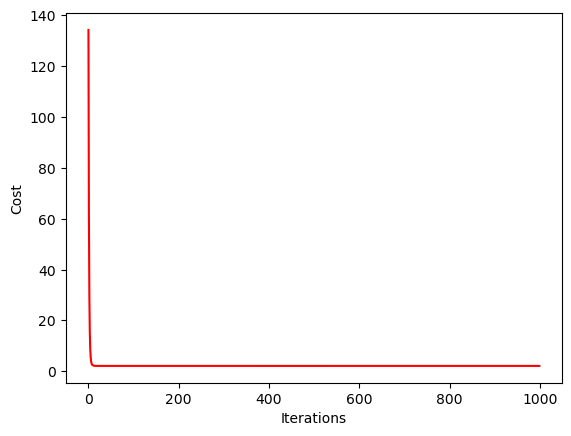

In [14]:
plt.plot (cost, color = "red")
plt.xlabel ("Iterations")
plt.ylabel ("Cost")
plt.show()

Calculating R Square of the model:

In [15]:
num_r = 0
den_r = 0
for i in range (len(x_test)):
    num_r += (y_test.iloc[i] - ((m * x_test.iloc[i]) + b))**2
    den_r += (y_test.iloc[i] - np.mean(y_test))**2
r_sqr = 1-(num_r/den_r)
print("The R square value is: ",r_sqr)

The R square value is:  -0.12887518481467497


### Q2: Linear Regression with Two Variables:

Splitting data into Test & Train - 80:20 Split:

In [16]:
def df_split(df,test_split):
    array_lenght = len(df)
    test_num = int(array_lenght * test_split)
    
    x1_train = df[:-test_num]["Mean Texture"]
    x2_train = df[:-test_num]["Lymph Node Status"]
    y_train = df[:-test_num]["Tumor Size"]
    x1_test = df[-test_num:]["Mean Texture"]
    x2_test = df[-test_num:]["Lymph Node Status"]
    y_test = df[-test_num:]["Tumor Size"]
    
    return x1_train, x2_train, y_train, x1_test, x2_test, y_test

In [17]:
x1_train, x2_train, y_train, x1_test, x2_test, y_test = df_split(df,0.2)

x1_train, x2_train, y_train, x1_test, x2_test, y_test

(0      27.60
 1      10.38
 2      17.44
 3      20.38
 4      14.34
        ...  
 154    19.51
 155    18.82
 156    20.20
 157    20.56
 158    17.52
 Name: Mean Texture, Length: 156, dtype: float64,
 0      5.0
 1      2.0
 2      0.0
 3      0.0
 4      0.0
       ... 
 154    0.0
 155    9.0
 156    0.0
 157    2.0
 158    0.0
 Name: Lymph Node Status, Length: 156, dtype: float64,
 0      5.0
 1      3.0
 2      2.5
 3      2.0
 4      3.5
       ... 
 154    1.0
 155    7.0
 156    2.5
 157    3.5
 158    3.0
 Name: Tumor Size, Length: 156, dtype: float64,
 159    21.24
 160    24.49
 161    18.74
 162    23.95
 163    19.07
 164    20.58
 165    20.26
 166    21.60
 167    31.39
 168    30.62
 169    25.09
 170    22.39
 171    28.25
 172    28.08
 173    23.83
 174    26.17
 175    30.64
 176    25.28
 177    30.99
 178    25.48
 179    26.79
 180    17.10
 181    20.88
 182    24.51
 183    27.42
 184    23.96
 185    24.70
 186    33.87
 187    29.95
 188    30.98
 189    2

In [18]:
def cost_function_two(m1,m2,b,xi,xj,yi): #Loss Function/Mean Square Error
    total_error = 0
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        y = yi.iloc[i]
        
        y_pred = (m1 * x1) + (m2 * x2) + b
        
        total_error += (y - (y_pred))**2
        
    return total_error/(2*len(xi))

In [19]:
def gradiant_descent_two (m1_now ,m2_now,b_now, xi,xj,yi, l):
    m1_gradiant = 0
    m2_gradiant = 0
    b_gradiant = 0
    
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        y = yi.iloc[i]
    
        m1_gradiant += -(1/n) * x1 * (y - ((m1_now * x1) + (m2_now * x2) + b_now))
        m2_gradiant += -(1/n) * x2 * (y - ((m1_now * x1) + (m2_now * x2) + b_now))
        b_gradiant += -(1/n) * (y - ((m1_now * x1) + (m2_now * x2) + b_now))
        
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l
    b = b_now - b_gradiant * l
    return m1,m2,b

Calling the Cost & Gradient Descent Functions:

In [20]:
m1 = 1
m2 = 1
b = 1
itr = 100
l = 0.0007
cost_train = []
cost_test = []
y_pred = []
for i in range (itr):
    m1, m2, b = gradiant_descent_two(m1,m2,b,x1_train,x2_train,y_train,l)
#    cost_train.append(cost_function_two (m1,m2,b,x1_train,x2_train,y_train))
    cost_test.append(cost_function_two (m1,m2,b,x1_test,x2_test,y_test))
    
for i in range (len(x1_test)):
        x1 = x1_test.iloc[i]
        x2 = x2_test.iloc[i]
        y = y_test.iloc[i]
        
        y_pred.append((m1 * x1) + (m2 * x2) + b)

print("The value of m1 is: ",m1,"\nThe value of m2 is: ",m2,"\nThe value of b is: ",b)
print("\nThe minimum Cost of the model is: ",min(cost_test))

The value of m1 is:  0.047683545150693486 
The value of m2 is:  0.2559879799888188 
The value of b is:  0.9606623863486354

The minimum Cost of the model is:  1.840293116717243


Graph showing the cost of the Test variables

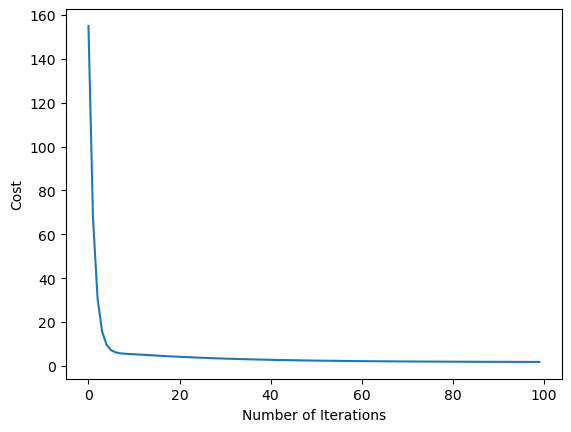

In [21]:
plt.plot (cost_test)
plt.xlabel ("Number of Iterations")
plt.ylabel ("Cost")
plt.show()

Calculating R Square of the model

In [22]:
num_r = 0
den_r = 0
for i in range (len(x1_test)):
    num_r += (y_test.iloc[i] - ((m1 * x1_test.iloc[i]) + (m2 * x2_test.iloc[i]) + b))**2
    den_r += (y_test.iloc[i] - np.mean(y_test))**2
r_sqr = 1-(num_r/den_r)
print ("The R Square value is: ",r_sqr)

The R Square value is:  0.021416270598224152


Calculating BIC of the model

In [23]:
k = 3
n = len(y_test)
    
for i in range (len(x1_test)):
    y_pred = (m1 * x1_test.iloc[i]) + (m2 * x2_test.iloc[i]) + b
    SSE = -np.sum(((y_test.iloc[i] - y_pred) ** 2) / n)

BIC = n * SSE + k * np.log(n)
print ("The BIC value is: ",BIC)

The BIC value is:  9.477555704583487


### Q3a. Stepwise Linear Regression - Forward:

Selecting 5 features and splitting each feature for Training & Testing:

In [24]:
def df_split_forward(df,test_split):
    array_lenght = len(df)
    test_num = int(array_lenght * test_split)
    
    x1_train = df[:-test_num]["Mean Symmetry"]
    x1_test = df[-test_num:]["Mean Symmetry"]
    
    x2_train = df[:-test_num]["Mean Fractal Dimension"]
    x2_test = df[-test_num:]["Mean Fractal Dimension"]
    
    x3_train = df[:-test_num]["Worst Radius"]
    x3_test = df[-test_num:]["Worst Radius"]
    
    x4_train = df[:-test_num]["Lymph Node Status"]
    x4_test = df[-test_num:]["Lymph Node Status"]
    
    x5_train = df[:-test_num]["Worst Symmetry"]
    x5_test = df[-test_num:]["Worst Symmetry"]
    
    y_test = df[-test_num:]["Tumor Size"]
    y_train = df[:-test_num]["Tumor Size"]
    
    return x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, x5_train, x5_test, y_train, y_test

In [25]:
x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, x5_train, x5_test, y_train, y_test = df_split_forward(df,0.2)

x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, x5_train, x5_test, y_train, y_test

(0      0.1865
 1      0.2419
 2      0.2333
 3      0.2597
 4      0.1809
         ...  
 154    0.2151
 155    0.1823
 156    0.1846
 157    0.2116
 158    0.1832
 Name: Mean Symmetry, Length: 156, dtype: float64,
 159    0.1848
 160    0.2275
 161    0.1591
 162    0.1807
 163    0.1561
 164    0.1860
 165    0.1802
 166    0.1991
 167    0.1855
 168    0.2128
 169    0.2149
 170    0.1726
 171    0.1752
 172    0.1590
 173    0.1433
 174    0.2063
 175    0.1796
 176    0.1424
 177    0.1603
 178    0.2307
 179    0.1580
 180    0.1890
 181    0.1971
 182    0.1995
 183    0.2524
 184    0.1981
 185    0.1791
 186    0.1799
 187    0.2099
 188    0.1993
 189    0.1620
 190    0.1600
 191    0.1924
 192    0.2079
 193    0.1728
 194    0.1735
 195    0.1793
 197    0.1890
 Name: Mean Symmetry, dtype: float64,
 0      0.06333
 1      0.07871
 2      0.06010
 3      0.09744
 4      0.05883
         ...   
 154    0.06578
 155    0.06115
 156    0.05325
 157    0.06077
 158    0.06697


##### Iteration 1: Calculating Gradient Descent, MSE (Cost) and BIC each Variable separately

In [26]:
def gradiant_descent_1 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi, l):
    m1_gradiant = 0
    m2_gradiant = 0
    m3_gradiant = 0
    m4_gradiant = 0
    m5_gradiant = 0

    b1_gradiant = 0
    b2_gradiant = 0
    b3_gradiant = 0
    b4_gradiant = 0
    b5_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred1 = (m1_now * x1) + b1_now
        y_pred2 = (m2_now * x2) + b2_now
        y_pred3 = (m3_now * x3) + b3_now
        y_pred4 = (m4_now * x4) + b4_now
        y_pred5 = (m5_now * x5) + b5_now
        
        m1_gradiant = -(1/n) * np.sum(x1 * (y_pred1 - y))
        m2_gradiant = -(1/n) * np.sum(x2 * (y_pred2 - y))
        m3_gradiant = -(1/n) * np.sum(x3 * (y_pred3 - y))
        m4_gradiant = -(1/n) * np.sum(x4 * (y_pred4 - y))
        m5_gradiant = -(1/n) * np.sum(x5 * (y_pred5 - y))
        
        b1_gradiant = -(1/n) * np.sum((y - y_pred1))
        b2_gradiant = -(1/n) * np.sum((y - y_pred2))
        b3_gradiant = -(1/n) * np.sum((y - y_pred3))
        b4_gradiant = -(1/n) * np.sum((y - y_pred4))
        b5_gradiant = -(1/n) * np.sum((y - y_pred5))
        
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l
    m3 = m3_now - m3_gradiant * l
    m4 = m4_now - m4_gradiant * l
    m5 = m5_now - m5_gradiant * l
    
    b1 = b1_now - b1_gradiant * l
    b2 = b2_now - b2_gradiant * l
    b3 = b3_now - b3_gradiant * l
    b4 = b4_now - b4_gradiant * l
    b5 = b5_now - b5_gradiant * l
    
    return m1,m2,m3,m4,m5,b1,b2,b3,b4,b5

In [27]:
def cost_function_1(m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
    
    total_error1 = 0
    total_error2 = 0
    total_error3 = 0
    total_error4 = 0
    total_error5 = 0
    
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m1 * x1) + b1
        y_pred2 = (m2 * x2) + b2
        y_pred3 = (m3 * x3) + b3
        y_pred4 = (m4 * x4) + b4
        y_pred5 = (m5 * x5) + b5
        
        total_error1 = (np.sum((y - (y_pred1))**2))/(2*len(xi))
        total_error2 = (np.sum((y - (y_pred2))**2))/(2*len(xi))
        total_error3 = (np.sum((y - (y_pred3))**2))/(2*len(xi))
        total_error4 = (np.sum((y - (y_pred4))**2))/(2*len(xi))
        total_error5 = (np.sum((y - (y_pred5))**2))/(2*len(xi))
        
    return total_error1, total_error2, total_error3, total_error4, total_error5

In [28]:
def bic_1 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 2
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m1 * x1) + b1
        y_pred2 = (m2 * x2) + b2
        y_pred3 = (m3 * x3) + b3
        y_pred4 = (m4 * x4) + b4
        y_pred5 = (m5 * x5) + b5
    
        SSE1 = -np.sum(((y - y_pred1) ** 2) / n)
        SSE2 = -np.sum(((y - y_pred2) ** 2) / n)
        SSE3 = -np.sum(((y - y_pred3) ** 2) / n)
        SSE4 = -np.sum(((y - y_pred4) ** 2) / n)
        SSE5 = -np.sum(((y - y_pred5) ** 2) / n)

    BIC1 = n * SSE1 + k * np.log(n)
    BIC2 = n * SSE2 + k * np.log(n)
    BIC3 = n * SSE3 + k * np.log(n) 
    BIC4 = n * SSE4 + k * np.log(n)
    BIC5 = n * SSE5 + k * np.log(n)
    
    return BIC1,BIC2,BIC3,BIC4,BIC5

Calling the above functions and finding the Gradient Descent, Cost & BIC of the model:

In [29]:
m1 = 1
m2 = 1
m3 = 1
m4 = 1
m5 = 1

b1 = 1
b2 = 1
b3 = 1
b4 = 1
b5 = 1

itr = 100
l = 0.0001

cost_train1 = []
cost_test1 = []

for i in range (itr):
    m1, m2, m3, m4, m5, b1, b2, b3, b4, b5 = gradiant_descent_1(m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train1.append(cost_function_1 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test1.append(cost_function_1 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))
    
    bic1,bic2,bic3,bic4,bic5 = bic_1(m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)


print("The value of m1 is: ",m1,"\nThe value of m2 is: ",m2,"\nThe value of m3 is: ",m3,"\nThe value of m4 is: ",m4,"\nThe value of m5 is: ",m5,)
print("The value of b1 is: ",b1,"\nThe value of b2 is: ",b2,"\nThe value of b3 is: ",b3,"\nThe value of b4 is: ",b4,"\nThe value of b5 is: ",b5,)

print("\nThe minimum Cost of the model is: ",min(cost_test1))

print("\nBIC values:")
print("Mean Symmetry: ", {bic1})
print("Mean Fractal Dimension: ", {bic2})
print("Worst Radius: ", {bic3})
print("Lymph Node Status: ", {bic4})
print("Worst Symmetry: ", {bic5})

The value of m1 is:  0.9999786649004191 
The value of m2 is:  0.999991701863468 
The value of m3 is:  1.0307618214033456 
The value of m4 is:  1.0 
The value of m5 is:  0.9999718598751235
The value of b1 is:  1.0001164579671458 
The value of b2 is:  1.000123908265373 
The value of b3 is:  0.9986478320262262 
The value of b4 is:  1.0001282010602421 
The value of b5 is:  1.0001121120512997

The minimum Cost of the model is:  (0.0702658076495039, 0.07830644731114748, 4.190469128717373, 0.08222840804124079, 0.06347575356611534)

BIC values:
Mean Symmetry:  {1.9349709380904754}
Mean Fractal Dimension:  {1.3238823238055621}
Worst Radius:  {-311.20048146306755}
Lymph Node Status:  {1.0258133083184715}
Worst Symmetry:  {2.4510150484280047}


Since the Minimum Cost & BIC value of "Worst Symmetry" feature are prominent, we are going to choose this as our primary feature.

##### Iteration 2: Calculating Gradient Descent, MSE and R Square for Two Variables

In [30]:
def gradiant_descent_2 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi, l):
    m51_gradiant = 0
    m52_gradiant = 0
    m53_gradiant = 0
    m54_gradiant = 0

    b51_gradiant = 0
    b52_gradiant = 0
    b53_gradiant = 0
    b54_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred51 = (m1_now * x1) + (m5_now * x5) + b1_now
        y_pred52 = (m2_now * x2) + (m5_now * x5) + b2_now
        y_pred53 = (m3_now * x3) + (m5_now * x5) + b3_now
        y_pred54 = (m4_now * x4) + (m5_now * x5) + b4_now
        
        m51_gradiant = -(1/n) * np.sum(x1 * (y_pred51 - y))
        m52_gradiant = -(1/n) * np.sum(x2 * (y_pred52 - y))
        m53_gradiant = -(1/n) * np.sum(x3 * (y_pred53 - y))
        m54_gradiant = -(1/n) * np.sum(x4 * (y_pred54 - y))
        
        b51_gradiant = -(1/n) * np.sum((y - y_pred51))
        b52_gradiant = -(1/n) * np.sum((y - y_pred52))
        b53_gradiant = -(1/n) * np.sum((y - y_pred53))
        b54_gradiant = -(1/n) * np.sum((y - y_pred54))
        
    m51 = m1_now - m51_gradiant * l
    m52 = m2_now - m52_gradiant * l
    m53 = m3_now - m53_gradiant * l
    m54 = m4_now - m54_gradiant * l

    
    b51 = b1_now - b51_gradiant * l
    b52 = b2_now - b52_gradiant * l
    b53 = b3_now - b53_gradiant * l
    b54 = b4_now - b54_gradiant * l
    
    return m51,m52,m53,m54,b51,b52,b53,b54

In [31]:
def cost_function_2 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error51 = 0
    total_error52 = 0
    total_error53 = 0
    total_error54 = 0    
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred51 = (m1 * x1) + (m5 * x5) + b1
        y_pred52 = (m2 * x2) + (m5 * x5) + b2
        y_pred53 = (m3 * x3) + (m5 * x5) + b3
        y_pred54 = (m4 * x4) + (m5 * x5) + b4
        
        total_error51 = (np.sum((y - (y_pred51))**2))/(2*len(xi))
        total_error52 = (np.sum((y - (y_pred52))**2))/(2*len(xi))
        total_error53 = (np.sum((y - (y_pred53))**2))/(2*len(xi))
        total_error54 = (np.sum((y - (y_pred54))**2))/(2*len(xi))
        
    return total_error51, total_error52, total_error53, total_error54

In [32]:
def bic_2 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 3
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred51 = (m1 * x1) + (m5 * x5) + b1
        y_pred52 = (m2 * x2) + (m5 * x5) + b2
        y_pred53 = (m3 * x3) + (m5 * x5) + b3
        y_pred54 = (m4 * x4) + (m5 * x5) + b4
    
        SSE1 = -np.sum(((y - y_pred51) ** 2) / n)
        SSE2 = -np.sum(((y - y_pred52) ** 2) / n)
        SSE3 = -np.sum(((y - y_pred53) ** 2) / n)
        SSE4 = -np.sum(((y - y_pred54) ** 2) / n)

    BIC51 = n * SSE1 + k * np.log(n)
    BIC52 = n * SSE2 + k * np.log(n)
    BIC53 = n * SSE3 + k * np.log(n)
    BIC54 = n * SSE4 + k * np.log(n)
    
    return BIC51,BIC52,BIC53,BIC54

Calling the above functions and finding the Gradient Descent, Cost & BIC of the model:

In [33]:
m51 = 1
m52 = 1
m53 = 1
m54 = 1
m55 = 1

b51 = 1
b52 = 1
b53 = 1
b54 = 1
b55 = 1

itr = 100
l = 0.0001

cost_train2 = []
cost_test2 = []

for i in range (itr):
    m51, m52, m53, m54, b51, b52, b53, b54 = gradiant_descent_2 (m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train2.append(cost_function_2 (m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test2.append(cost_function_2 (m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))
   
    bic51,bic52,bic53,bic54 = bic_2(m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)


print("The value of m51 is: ",m51,"\nThe value of m52 is: ",m52,"\nThe value of m53 is: ",m53,"\nThe value of m54 is: ",m54)
print("The value of b51 is: ",b51,"\nThe value of b52 is: ",b52,"\nThe value of b53 is: ",b53,"\nThe value of b54 is: ",b54)

print("\nThe minimum Cost of the model is: ",min(cost_test2))

print("\nBIC values:")
print("\nMean Symmetry + Worst Symetry: ", {bic51})
print("Mean Fractal Dimension + Worst Symetry: ", {bic52})
print("Worst Radius + Worst Symetry: ", {bic53})
print("Lymph Node Status + Worst Symetry: ", {bic54})


The value of m51 is:  0.9999816124510548 
The value of m52 is:  0.9999927793595593 
The value of m53 is:  1.0311339282550176 
The value of m54 is:  1.0
The value of b51 is:  1.0001003687169507 
The value of b52 is:  1.0001078190300237 
The value of b53 is:  0.9986314756810981 
The value of b54 is:  1.0001121118271818

The minimum Cost of the model is:  (0.053021937264545946, 0.060035237638299786, 4.337714573153522, 0.0634752599383191)

BIC values:

Mean Symmetry + Worst Symetry:  {6.883091247073665}
Mean Fractal Dimension + Worst Symetry:  {6.350080418668373}
Worst Radius + Worst Symetry:  {-318.75354908048854}
Lymph Node Status + Worst Symetry:  {6.0886387238669055}


Since the MSE & BIC values of Mean Symmetry + Worst Symmetry are effecient, we are going to choose this as our next feature.

#### Iteration 3: Calculating Gradient Descent, MSE and BIC for Three Variables.

In [34]:
def gradiant_descent_3 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi, l):
    m512_gradiant = 0
    m513_gradiant = 0
    m514_gradiant = 0

    b512_gradiant = 0
    b513_gradiant = 0
    b514_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred512 = (m2_now * x2) + (m5_now * x5) + (m1_now * x1) +  b2_now
        y_pred513 = (m3_now * x3) + (m5_now * x5) + (m1_now * x1) +  b3_now
        y_pred514 = (m4_now * x4) + (m5_now * x5) + (m1_now * x1) +  b4_now
        
        m512_gradiant = -(1/n) * np.sum(x2 * (y_pred512 - y))
        m513_gradiant = -(1/n) * np.sum(x3 * (y_pred513 - y))
        m514_gradiant = -(1/n) * np.sum(x4 * (y_pred514 - y))
        
        b512_gradiant = -(1/n) * np.sum((y - y_pred512))
        b513_gradiant = -(1/n) * np.sum((y - y_pred513))
        b514_gradiant = -(1/n) * np.sum((y - y_pred514))
        

    m512 = m2_now - m512_gradiant * l
    m513 = m3_now - m513_gradiant * l
    m514 = m4_now - m514_gradiant * l

    
    b512 = b2_now - b512_gradiant * l
    b513 = b3_now - b513_gradiant * l
    b514 = b4_now - b514_gradiant * l
    
    return m512,m513,m514,b512,b513,b514

In [38]:
def cost_function_3 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error512 = 0
    total_error513 = 0
    total_error514 = 0    
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred512 = (m2 * x2) + (m5 * x5) + (m1 * x1) + b2
        y_pred513 = (m3 * x3) + (m5 * x5) + (m1 * x1) + b3
        y_pred514 = (m4 * x4) + (m5 * x5) + (m1 * x1) + b4
        
        total_error512 = (np.sum((y - (y_pred512))**2))/(2*len(xi))
        total_error513 = (np.sum((y - (y_pred513))**2))/(2*len(xi))
        total_error514 = (np.sum((y - (y_pred514))**2))/(2*len(xi))
        
    return total_error512, total_error513, total_error514

In [39]:
def bic_3 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 4
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred512 = (m2 * x2) + (m5 * x5) + (m1 * x1) + b2
        y_pred513 = (m3 * x3) + (m5 * x5) + (m1 * x1) + b3
        y_pred514 = (m4 * x4) + (m5 * x5) + (m1 * x1) + b4
    
        SSE2 = -np.sum(((y - y_pred512) ** 2) / n)
        SSE3 = -np.sum(((y - y_pred513) ** 2) / n)
        SSE4 = -np.sum(((y - y_pred514) ** 2) / n)

    BIC512 = n * SSE2 + k * np.log(n)
    BIC513 = n * SSE3 + k * np.log(n)
    BIC514 = n * SSE4 + k * np.log(n)
    
    return BIC512,BIC513,BIC514

Calling the above functions and finding the Gradient Descent, Cost & BIC of the model:

In [40]:
m511 = 1
m512 = 1
m513 = 1
m514 = 1
m515 = 1

b511 = 1
b512 = 1
b513 = 1
b514 = 1
b515 = 1

itr = 100
l = 0.0001

cost_train3 = []
cost_test3 = []

for i in range (itr):
    m512, m513, m514, b512, b513, b514 = gradiant_descent_3 (m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train3.append(cost_function_3 (m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test3.append(cost_function_3 (m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))

    bic512,bic513,bic514 = bic_3(m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)

    
print("The value of m512 is: ",m512,"\nThe value of m513 is: ",m513,"\nThe value of m514 is: ",m514)
print("The value of b512 is: ",b512,"\nThe value of b53 is: ",b513,"\nThe value of b514 is: ",b514)

print("\nThe minimum Cost of the model is: ",min(cost_test3))

print("\nBIC values:")
print("Mean Fractal Dimension + Mean Symmetry + Worst Symetry: ", {bic512})
print("Worst Radius + Mean Symmetry + Worst Symetry: ", {bic513})
print("Lymph Node Status + Mean Symmetry + Worst Symetry: ", {bic514})

The value of m512 is:  0.9999935658029219 
The value of m513 is:  1.0314055217818174 
The value of m514 is:  1.0
The value of b512 is:  1.0000960758112347 
The value of b53 is:  0.9986195375040962 
The value of b514 is:  1.0001003686100645

The minimum Cost of the model is:  (0.04988184862889305, 4.431073284982266, 0.05302175368558485)

BIC values:
Mean Fractal Dimension + Mean Symmetry + Worst Symetry:  {10.759324143109671}
Worst Radius + Mean Symmetry + Worst Symetry:  {-322.2112250197467}
Lymph Node Status + Mean Symmetry + Worst Symetry:  {10.520691358801095}


Since the MSE & BIC values of Mean Fractal Dimension + Mean Symmetry + Worst Symetry are effecient, we are going to choose this as our next feature.

##### Iteration 4: Calculating Gradient Descent, MSE and BIC for Four Variables

In [41]:
def gradiant_descent_4 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi, l):

    m5123_gradiant = 0
    m5124_gradiant = 0

    b5123_gradiant = 0
    b5124_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred5123 = (m3_now * x3) + (m5_now * x5) + (m1_now * x1) + (m2_now * x2) + b3_now
        y_pred5124 = (m4_now * x4) + (m5_now * x5) + (m1_now * x1) + (m2_now * x2) + b4_now
        
        m5123_gradiant = -(1/n) * np.sum(x3 * (y_pred5123 - y))
        m5124_gradiant = -(1/n) * np.sum(x4 * (y_pred5124 - y))
        
        b5123_gradiant = -(1/n) * np.sum((y - y_pred5123))
        b5124_gradiant = -(1/n) * np.sum((y - y_pred5124))
        


    m5123 = m3_now - m5123_gradiant * l
    m5124 = m4_now - m5124_gradiant * l

    
    b5123 = b3_now - b5123_gradiant * l
    b5124 = b4_now - b5124_gradiant * l
    
    return m5123,m5124,b5123,b5124

In [42]:
def cost_function_4 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error5123 = 0
    total_error5124 = 0    
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred5123 = (m3 * x3) + (m5 * x5) + (m1 * x1) + (m2 * x2) + b3
        y_pred5124 = (m4 * x4) + (m5 * x5) + (m1 * x1) + (m2 * x2) + b4
        
        total_error5123 = (np.sum((y - (y_pred5123))**2))/(2*len(xi))
        total_error5124 = (np.sum((y - (y_pred5124))**2))/(2*len(xi))
        
    return total_error5123, total_error5124

In [43]:
def bic_4 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 5
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred5123 = (m3 * x3) + (m5 * x5) + (m1 * x1) + (m2 * x2) + b3
        y_pred5124 = (m4 * x4) + (m5 * x5) + (m1 * x1) + (m2 * x2) + b4
    

        SSE3 = -np.sum(((y - y_pred5123) ** 2) / n)
        SSE4 = -np.sum(((y - y_pred5124) ** 2) / n)

    BIC5123 = n * SSE3 + k * np.log(n)
    BIC5124 = n * SSE4 + k * np.log(n)
    
    return BIC5123,BIC5124

Calling the above functions and finding the Gradient Descent, Cost & BIC of the model:

In [44]:
m5121 = 1
m5122 = 1
m5123 = 1
m5124 = 1
m5125 = 1

b5121 = 1
b5122 = 1
b5123 = 1
b5124 = 1
b5125 = 1

itr = 100
l = 0.0001

cost_train4 = []
cost_test4 = []

for i in range (itr):
    m5123, m5124, b5123, b5124 = gradiant_descent_4 (m5121,m5122,m5123,m5124,m5125,b5121,b5122,b5123,b5124,b5125,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train4.append(cost_function_4 (m5121,m5122,m5123,m5124,m5125,b5121,b5122,b5123,b5124,b5125,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test4.append(cost_function_4 (m5121,m5122,m5123,m5124,m5125,b5121,b5122,b5123,b5124,b5125,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))
    
    bic5123,bic5124 = bic_4(m511,m512,m5123,m5124,m515,b511,b512,b5123,b5124,b515,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)

print("The value of m5123 is: ",m5123,"\nThe value of m5124 is: ",m5124)
print("The value of b523 is: ",b5123,"\nThe value of b5124 is: ",b5124)

print("\nThe minimum Cost of the model is: ",min(cost_test4))

print("\nBIC values:")
print("Worst Radius + Mean Fractal Dimension + Mean Symmetry + Worst Symetry: ", {bic5123})
print("Lymph Node Status + Mean Fractal Dimension + Mean Symmetry + Worst Symetry: ", {bic5124})

The value of m5123 is:  1.0315048046338358 
The value of m5124 is:  1.0
The value of b523 is:  0.9986151734226889 
The value of b5124 is:  1.0000960757975619

The minimum Cost of the model is:  (4.1684574415719275, 0.04988670238029497)

BIC values:
Worst Radius + Mean Fractal Dimension + Mean Symmetry + Worst Symetry:  {-320.86425028047853}
Lymph Node Status + Mean Fractal Dimension + Mean Symmetry + Worst Symetry:  {14.396910302782814}


Since the BIC value of Mean Fractal Dimension + Mean Symmetry + Worst Symmetry + Lymph Node Status is lower, we are going to choose this as our next feature

##### Iteration 5: Calculating Gradient Descent, MSE and BIC for Five Variables

In [45]:
def gradiant_descent_5 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi, l):

    m51243_gradiant = 0
    b51243_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred51243 = (m3_now * x3) + (m5_now * x5) + (m1_now * x1) + (m2_now * x2) + (m4_now * x4) + b3_now
        
        m51243_gradiant = -(1/n) * np.sum(x3 * (y_pred51243 - y))
        b51243_gradiant = -(1/n) * np.sum((y - y_pred51243))
        

    m51243 = m3_now - m51243_gradiant * l    
    b51243 = b3_now - b51243_gradiant * l
    
    return m51243,b51243

In [46]:
def cost_function_5 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error51243 = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred51243 = (m3 * x3) + (m5 * x5) + (m1 * x1) + (m2 * x2) + (m4 * x4) + b3
        
        total_error51243 = (np.sum((y - (y_pred51243))**2))/(2*len(xi))
        
    return total_error51243

In [47]:
def bic_5 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 6
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred51243 = (m3 * x3) + (m5 * x5) + (m1 * x1) + (m2 * x2) + (m4 * x4) + b3
    
        SSE3 = -np.sum(((y - y_pred51243) ** 2) / n)

    BIC51243 = n * SSE3 + k * np.log(n)
    
    return BIC51243

In [48]:
m51241 = 1
m51242 = 1
m51243 = 1
m51224 = 1
m51245 = 1

b51241 = 1
b51242 = 1
b51243 = 1
b51244 = 1
b51245 = 1

itr = 100
l = 0.0001

cost_train5 = []
cost_test5 = []

for i in range (itr):
    m51243, b51243 = gradiant_descent_5 (m51241,m51242,m51243,m5124,m51245,b51241,b51242,b51243,b5124,b51245,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train5.append(cost_function_5 (m51241,m51242,m51243,m5124,m51245,b51241,b51242,b51243,b5124,b51245,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test5.append(cost_function_5 (m51241,m51242,m51243,m5124,m51245,b51241,b51242,b51243,b5124,b51245,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))

    bic51243 = bic_5(m511,m512,m51243,m5124,m515,b511,b512,b51243,b5124,b515,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)

print("The value of m51243 is: ",m51243)
print("The value of b51243 is: ",b51243)

print("\nThe minimum Cost of the model is: ",min(cost_test5))

print("\nBIC values:")
print("Worst Radius + Worst Symmetry + Mean Symmetry + Mean Fractal Dimension + Lymph Node Status:", {bic51243})


The value of m51243 is:  1.0315048046338358
The value of b51243 is:  0.9986151734226889

The minimum Cost of the model is:  4.1684574415719275

BIC values:
Worst Radius + Worst Symmetry + Mean Symmetry + Mean Fractal Dimension + Lymph Node Status: {-317.22666412075216}


### Q3b. Stepwise Linear Regression - Backward:

Selecting 5 features and splitting each feature for Training & Testing:

In [49]:
def df_split_backward(df,test_split):
    array_lenght = len(df)
    test_num = int(array_lenght * test_split)
    
    x1_train = df[:-test_num]["Mean Radius"]
    x1_test = df[-test_num:]["Mean Radius"]
    
    x2_train = df[:-test_num]["Mean Fractal Dimension"]
    x2_test = df[-test_num:]["Mean Fractal Dimension"]
    
    x3_train = df[:-test_num]["Worst Radius"]
    x3_test = df[-test_num:]["Worst Radius"]
    
    x4_train = df[:-test_num]["Lymph Node Status"]
    x4_test = df[-test_num:]["Lymph Node Status"]
    
    x5_train = df[:-test_num]["Worst Symmetry"]
    x5_test = df[-test_num:]["Worst Symmetry"]
    
    y_test = df[-test_num:]["Tumor Size"]
    y_train = df[:-test_num]["Tumor Size"]
    
    return x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, x5_train, x5_test, y_train, y_test

In [50]:
x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, x5_train, x5_test, y_train, y_test = df_split_backward(df,0.2)

x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, x5_train, x5_test, y_train, y_test

(0      18.02
 1      17.99
 2      21.37
 3      11.42
 4      20.29
        ...  
 154    16.25
 155    19.44
 156    16.69
 157    18.01
 158    18.49
 Name: Mean Radius, Length: 156, dtype: float64,
 159    20.59
 160    13.82
 161    24.24
 162    15.46
 163    15.05
 164    18.31
 165    19.89
 166    24.63
 167    18.45
 168    15.22
 169    20.92
 170    21.56
 171    20.13
 172    16.60
 173    13.86
 174    18.11
 175    21.93
 176    17.53
 177    18.11
 178    24.29
 179    15.60
 180    15.78
 181    19.28
 182    15.66
 183    22.44
 184    17.98
 185    13.63
 186    23.01
 187    22.41
 188    12.53
 189    19.80
 190    19.96
 191    19.22
 192    14.72
 193    22.52
 194    15.44
 195    17.17
 197    16.70
 Name: Mean Radius, dtype: float64,
 0      0.06333
 1      0.07871
 2      0.06010
 3      0.09744
 4      0.05883
         ...   
 154    0.06578
 155    0.06115
 156    0.05325
 157    0.06077
 158    0.06697
 Name: Mean Fractal Dimension, Length: 156, dtype: fl

##### Iteration 1: Calculating Gradient Descent, MSE (Cost) and BIC the whole model.

In [51]:
def gradiant_descent_11 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi, l):
    m1_gradiant = 0
    m2_gradiant = 0
    m3_gradiant = 0
    m4_gradiant = 0
    m5_gradiant = 0

    b_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred = (m1_now * x1) + (m2_now * x2) + (m3_now * x3) + (m4_now * x4) + (m5_now * x5) + b1_now
        
        m1_gradiant = -(1/n) * np.sum(x1 * (y - y_pred))
        m2_gradiant = -(1/n) * np.sum(x2 * (y - y_pred))
        m3_gradiant = -(1/n) * np.sum(x3 * (y - y_pred))
        m4_gradiant = -(1/n) * np.sum(x4 * (y - y_pred))
        m5_gradiant = -(1/n) * np.sum(x5 * (y - y_pred))
        
        b1_gradiant = -(1/n) * np.sum((y - y_pred))
        b2_gradiant = -(1/n) * np.sum((y - y_pred))
        b3_gradiant = -(1/n) * np.sum((y - y_pred))
        b4_gradiant = -(1/n) * np.sum((y - y_pred))
        b5_gradiant = -(1/n) * np.sum((y - y_pred))
        
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l
    m3 = m3_now - m3_gradiant * l
    m4 = m4_now - m4_gradiant * l
    m5 = m5_now - m5_gradiant * l
    
    b = b1_now - b_gradiant * l
    
    return m1,m2,m3,m4,m5,b

In [52]:
def cost_function_11(m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred = (m1 * x1) + (m2 * x2) + (m3 * x3) + (m4 * x4) + (m5 * x5) + b1
        
        total_error = (np.sum((y - (y_pred))**2))/(2*len(xi))
        
    return total_error

In [53]:
def bic_11 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 2
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred = (m1 * x1) + (m2 * x2) + (m3 * x3) + (m4 * x4) + (m5 * x5) + b1
    
        SSE = np.sum(((y- y_pred) ** 2) / n)

    BIC = n * SSE + k * np.log(n)
        
    return BIC

Calling the above functions to find out the Gradient Descent, Cost & BIC:

In [54]:
m1 = 1
m2 = 1
m3 = 1
m4 = 1
m5 = 1

b1 = 1
b2 = 1
b3 = 1
b4 = 1
b5 = 1

itr = 100
l = 0.0001

cost_train1 = []
cost_test1 = []

for i in range (itr):
    m1, m2, m3, m4, m5, b = gradiant_descent_11(m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train1.append(cost_function_11 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test1.append(cost_function_11 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))
    
    BIC = bic_11(m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)

print("The value of m1 is: ",m1,"\nThe value of m2 is: ",m2,"\nThe value of m3 is: ",m3,"\nThe value of m4 is: ",m4,"\nThe value of m5 is: ",m5,)
print("The value of b1 is: ",b1,"\nThe value of b2 is: ",b2,"\nThe value of b3 is: ",b3,"\nThe value of b4 is: ",b4,"\nThe value of b5 is: ",b5,)

print("\nThe minimum Cost of the model is: ",min(cost_test1))

print("BIC values:")
print("Worst Radius + Worst Symmetry + Mean Radius + Mean Fractal Dimension + Lymph Node Status: ", {BIC})

The value of m1 is:  0.9543696790113501 
The value of m2 is:  0.9998347289022926 
The value of m3 is:  0.943856689967994 
The value of m4 is:  1.0 
The value of m5 is:  0.9993805727112953
The value of b1 is:  1 
The value of b2 is:  1 
The value of b3 is:  1 
The value of b4 is:  1 
The value of b5 is:  1

The minimum Cost of the model is:  13.84108722001664
BIC values:
Worst Radius + Worst Symmetry + Mean Radius + Mean Fractal Dimension + Lymph Node Status:  {1059.1978010407174}


These are the values of the model with all the variables combined.

##### Iteration 2: Calculating Gradient Descent, MSE and BIC of each feature after removing 1 variable

In [55]:
def gradiant_descent_12 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi,l):
    
    m1_gradiant = 0
    m2_gradiant = 0
    m3_gradiant = 0
    m4_gradiant = 0
    m5_gradiant = 0

    b1_gradiant = 0
    b2_gradiant = 0
    b3_gradiant = 0
    b4_gradiant = 0
    b5_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred1 = (m2_now * x2) + (m3_now * x3) + (m4_now * x4) + (m5_now * x5) + b1_now
        y_pred2 = (m1_now * x1) + (m3_now * x3) + (m4_now * x4) + (m5_now * x5) + b1_now
        y_pred3 = (m1_now * x1) + (m2_now * x2) + (m4_now * x4) + (m5_now * x5) + b1_now
        y_pred4 = (m1_now * x1) + (m2_now * x2) + (m3_now * x3) + (m5_now * x5) + b1_now
        y_pred5 = (m1_now * x1) + (m2_now * x2) + (m3_now * x3) + (m4_now * x4) + b1_now
        
        m1_gradiant = -(1/n) * np.sum(x1 * (y_pred1 - y))
        m2_gradiant = -(1/n) * np.sum(x2 * (y_pred2 - y))
        m3_gradiant = -(1/n) * np.sum(x2 * (y_pred2 - y))
        m4_gradiant = -(1/n) * np.sum(x4 * (y_pred4 - y))
        m5_gradiant = -(1/n) * np.sum(x5 * (y_pred5 - y))
        
        b1_gradiant = -(1/n) * np.sum((y - y_pred1))
        b2_gradiant = -(1/n) * np.sum((y - y_pred2))
        b3_gradiant = -(1/n) * np.sum((y - y_pred2))
        b4_gradiant = -(1/n) * np.sum((y - y_pred4))
        b5_gradiant = -(1/n) * np.sum((y - y_pred5))
        
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l
    m3 = m2_now - m2_gradiant * l
    m4 = m4_now - m4_gradiant * l
    m5 = m5_now - m5_gradiant * l

    
    b1 = b1_now - b1_gradiant * l
    b2 = b2_now - b2_gradiant * l
    b3 = b2_now - b3_gradiant * l
    b4 = b4_now - b4_gradiant * l
    b5 = b5_now - b5_gradiant * l
    
    return m1,m2,m3,m4,m5,b1,b2,b3,b4,b5

In [56]:
def cost_function_12 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error1 = 0
    total_error2 = 0
    total_error3 = 0
    total_error4 = 0
    total_errro5 = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m2 * x2) + (m3 * x3) + (m4 * x4) + (m5 * x5) + b1
        y_pred2 = (m1 * x1) + (m3 * x3) + (m4 * x4) + (m5 * x5) + b1
        y_pred3 = (m1 * x1) + (m2 * x2) + (m4 * x4) + (m5 * x5) + b1
        y_pred4 = (m1 * x1) + (m2 * x3) + (m3 * x3) + (m5 * x5) + b1
        y_pred5 = (m1 * x1) + (m2 * x2) + (m4 * x4) + (m3 * x3) + b1
        
        total_error1 = (np.sum((y - (y_pred1))**2))/(2*len(xi))
        total_error2 = (np.sum((y - (y_pred2))**2))/(2*len(xi))
        total_error3 = (np.sum((y - (y_pred3))**2))/(2*len(xi))
        total_error4 = (np.sum((y - (y_pred4))**2))/(2*len(xi))
        total_error5 = (np.sum((y - (y_pred5))**2))/(2*len(xi))
        
    return total_error1, total_error2, total_error4, total_error5

In [57]:
def bic_12 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 4
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m2 * x2) + (m3 * x3) + (m4 * x4) + (m5 * x5) + b1
        y_pred2 = (m1 * x1) + (m3 * x3) + (m4 * x4) + (m5 * x5) + b1
        y_pred3 = (m1 * x1) + (m2 * x2) + (m4 * x4) + (m5 * x5) + b1
        y_pred4 = (m1 * x1) + (m2 * x3) + (m3 * x3) + (m5 * x5) + b1
        y_pred5 = (m1 * x1) + (m2 * x2) + (m4 * x4) + (m3 * x3) + b1
    
        SSE1 = -np.sum(((y - y_pred1) ** 2) / n)
        SSE2 = -np.sum(((y - y_pred2) ** 2) / n)
        SSE3 = -np.sum(((y - y_pred3) ** 2) / n)
        SSE4 = -np.sum(((y - y_pred4) ** 2) / n)
        SSE5 = -np.sum(((y - y_pred5) ** 2) / n)

    BIC1 = n * SSE1 + k * np.log(n)
    BIC2 = n * SSE2 + k * np.log(n)
    BIC3 = n * SSE3 + k * np.log(n)
    BIC4 = n * SSE4 + k * np.log(n)
    BIC5 = n * SSE5 + k * np.log(n)

    
    return BIC1,BIC2,BIC3,BIC4,BIC5

Calling the above functions:

In [58]:
m51 = 1
m52 = 1
m53 = 1
m54 = 1
m55 = 1

b51 = 1
b52 = 1
b53 = 1
b54 = 1
b55 = 1

itr = 100
l = 0.0001

cost_train2 = []
cost_test2 = []

for i in range (itr):
    m51, m52, m53, m54, m55, b51, b52, b53, b54,b55 = gradiant_descent_12 (m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train2.append(cost_function_12 (m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test2.append(cost_function_12 (m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))
   
    bic51,bic52,bic53,bic54,bic55 = bic_12(m51,m52,m53,m54,m55,b51,b52,b53,b54,b55,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)

    
print("The value of m51 is: ",m51,"\nThe value of m52 is: ",m52,"\nThe value of m53 is: ",m53,"\nThe value of m54 is: ",m54,"\nThe value of m55 is: ",m55,)
print("The value of b51 is: ",b51,"\nThe value of b52 is: ",b52,"\nThe value of b53 is: ",b53,"\nThe value of b54 is: ",b54,"\nThe value of b55 is: ",b55,)

print("\nThe minimum Cost of the model is: ",min(cost_test2))

print("\nBIC values:")
print("Worst Radius + Worst Symmetry + Mean Fractal Dimension + Lymph Node Status:",bic51)
print("Worst Radius + Worst Symmetry + Mean Radius + Lymph Node Status",bic52)
print("Worst Symmetry + Mean Radius + Mean Fractal Dimension + Lymph Node Status",bic53)
print("Worst Radius + Worst Symmetry + Mean Radius + Mean Fractal Dimension",bic54)
print("Worst Radius + Mean Radius + Mean Fractal Dimension + Lymph Node Status",bic55)


The value of m51 is:  1.0249725258206583 
The value of m52 is:  1.000170519718889 
The value of m53 is:  1.000170519718889 
The value of m54 is:  1.0 
The value of m55 is:  1.0006361366679788
The value of b51 is:  0.9986494036873633 
The value of b52 is:  0.9974537894745514 
The value of b53 is:  0.9974537894745514 
The value of b54 is:  0.9974494961641899 
The value of b55 is:  0.9974655909642266

The minimum Cost of the model is:  (4.077583010185466, 15.43295275339162, 38.35098031595417, 15.214588881117951)

BIC values:
Worst Radius + Worst Symmetry + Mean Fractal Dimension + Lymph Node Status: -295.4233147008125
Worst Radius + Worst Symmetry + Mean Radius + Lymph Node Status -1186.9558729316425
Worst Symmetry + Mean Radius + Mean Fractal Dimension + Lymph Node Status -209.84238396601376
Worst Radius + Worst Symmetry + Mean Radius + Mean Fractal Dimension -2945.475088634711
Worst Radius + Mean Radius + Mean Fractal Dimension + Lymph Node Status -1170.1459175070277


Let's eliminate another variable to further calculate the BICs

##### Iteration 3: Calculating Gradient Descent, MSE and BIC of each feature after removing the next variable (2 variables eliminated)

In [59]:
def gradiant_descent_13 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi,l):
    
    m1_gradiant = 0
    m2_gradiant = 0
    m3_gradiant = 0
    m4_gradiant = 0
    m5_gradiant = 0

    b1_gradiant = 0
    b2_gradiant = 0
    b3_gradiant = 0
    b4_gradiant = 0
    b5_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred1 = (m2_now * x2) + (m3_now * x3) + (m5_now * x5) + b1_now
        y_pred2 = (m1_now * x1) + (m3_now * x3) + (m5_now * x5) + b1_now
        y_pred3 = (m1_now * x1) + (m2_now * x2) + (m5_now * x5) + b1_now
        y_pred4 = (m1_now * x1) + (m2_now * x2) + (m3_now * x3) + b1_now
        
        m1_gradiant = -(1/n) * np.sum(x1 * (y_pred1 - y))
        m2_gradiant = -(1/n) * np.sum(x2 * (y_pred2 - y))
        m3_gradiant = -(1/n) * np.sum(x2 * (y_pred3 - y))
        m5_gradiant = -(1/n) * np.sum(x5 * (y_pred4 - y))
        
        b1_gradiant = -(1/n) * np.sum((y - y_pred1))
        b2_gradiant = -(1/n) * np.sum((y - y_pred2))
        b3_gradiant = -(1/n) * np.sum((y - y_pred3))
        b5_gradiant = -(1/n) * np.sum((y - y_pred4))
        
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l
    m3 = m2_now - m2_gradiant * l
    m5 = m5_now - m5_gradiant * l

    
    b1 = b1_now - b1_gradiant * l
    b2 = b2_now - b2_gradiant * l
    b3 = b2_now - b3_gradiant * l
    b5 = b5_now - b5_gradiant * l
    
    return m1,m2,m3,m5,b1,b2,b3,b5

In [60]:
def cost_function_13 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error1 = 0
    total_error2 = 0
    total_error3 = 0
    total_error4 = 0
    total_errro5 = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m2 * x2) + (m3 * x3) + (m5 * x5) + b1
        y_pred2 = (m1 * x1) + (m3 * x3) + (m5 * x5) + b1
        y_pred3 = (m1 * x1) + (m2 * x2) + (m5 * x5) + b1
        y_pred4 = (m1 * x1) + (m2 * x3) + (m3 * x3) + b1
        
        total_error1 = (np.sum((y - (y_pred1))**2))/(2*len(xi))
        total_error2 = (np.sum((y - (y_pred2))**2))/(2*len(xi))
        total_error3 = (np.sum((y - (y_pred3))**2))/(2*len(xi))
        total_error4 = (np.sum((y - (y_pred4))**2))/(2*len(xi))
        
    return total_error1, total_error2, total_error3, total_error4

In [61]:
def bic_13 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 3
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m2 * x2) + (m3 * x3) + (m5 * x5) + b1
        y_pred2 = (m1 * x1) + (m3 * x3) + (m5 * x5) + b1
        y_pred3 = (m1 * x1) + (m2 * x2) + (m5 * x5) + b1
        y_pred4 = (m1 * x1) + (m2 * x3) + (m3 * x3) + b1
    
        SSE1 = -np.sum(((y - y_pred1) ** 2) / n)
        SSE2 = -np.sum(((y - y_pred2) ** 2) / n)
        SSE3 = -np.sum(((y - y_pred3) ** 2) / n)
        SSE4 = -np.sum(((y - y_pred4) ** 2) / n)

    BIC1 = n * SSE1 + k * np.log(n)
    BIC2 = n * SSE2 + k * np.log(n)
    BIC3 = n * SSE3 + k * np.log(n)
    BIC4 = n * SSE4 + k * np.log(n)
    
    return BIC1,BIC2,BIC3,BIC4

Calling the above functions to calculate Gradient Descent, MSE & BIC.

In [62]:
m511 = 1
m512 = 1
m513 = 1
m514 = 1
m515 = 1

b511 = 1
b512 = 1
b513 = 1
b514 = 1
b515 = 1

itr = 100
l = 0.0001

cost_train3 = []
cost_test3 = []

for i in range (itr):
    m511, m512, m513, m514, b511,b512, b513, b514 = gradiant_descent_13 (m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train3.append(cost_function_13 (m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test3.append(cost_function_13 (m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))

    bic11,bic12,bic13,bic14 = bic_13(m511,m512,m513,m514,m515,b511,b512,b513,b514,b515,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)

    
print("The value of m511 is: ",m511,"\nThe value of m512 is: ",m512,"\nThe value of m513 is: ",m513,"\nThe value of m514 is: ",m514)
print("The value of b511 is: ",b511,"\nThe value of b512 is: ",b512,"\nThe value of b513 is: ",b513,"\nThe value of b54 is: ",b514)

print("\nThe minimum Cost of the model is: ",min(cost_test3))

print("\nBIC values:")
print("Worst Radius + Mean Fractal Dimension + Lymph Node Status:",bic11)
print("Worst Radius + Mean Radius + Lymph Node Status",bic12)
print("Mean Radius + Mean Fractal Dimension + Lymph Node Status",bic13)
print("Worst Radius + Mean Radius + Mean Fractal Dimension",bic14)



The value of m511 is:  1.0249724323259144 
The value of m512 is:  1.0001705193778334 
The value of m513 is:  1.0001705193778334 
The value of m514 is:  1.0000063983451188
The value of b511 is:  0.9986494087438659 
The value of b512 is:  0.9974537945672174 
The value of b513 is:  0.9974683374255465 
The value of b54 is:  0.9999745085851839

The minimum Cost of the model is:  (4.077582120980321, 15.432951023475338, 2.7924581648709093, 37.92099816840829)

BIC values:
Worst Radius + Mean Fractal Dimension + Lymph Node Status: -299.0541025194412
Worst Radius + Mean Radius + Lymph Node Status -1190.5799662714633
Mean Radius + Mean Fractal Dimension + Lymph Node Status -213.47413933408927
Worst Radius + Mean Radius + Mean Fractal Dimension -2916.15921404077


Let's eliminate another variable to further calculate BICs

##### Iteration 4: Calculating Gradient Descent, MSE and BIC for remaining varaiables.

In [63]:
def gradiant_descent_14 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi,l):
    
    m1_gradiant = 0
    m2_gradiant = 0
    m3_gradiant = 0
    m4_gradiant = 0
    m5_gradiant = 0

    b1_gradiant = 0
    b2_gradiant = 0
    b3_gradiant = 0
    b4_gradiant = 0
    b5_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred1 = (m2_now * x2) + (m3_now * x3) + b1_now
        y_pred2 = (m1_now * x1) + (m3_now * x3) + b1_now
        y_pred3 = (m1_now * x1) + (m2_now * x2) + b1_now
        
        m1_gradiant = -(1/n) * np.sum(x1 * (y_pred1 - y))
        m2_gradiant = -(1/n) * np.sum(x2 * (y_pred2 - y))
        m3_gradiant = -(1/n) * np.sum(x2 * (y_pred3 - y))
        
        b1_gradiant = -(1/n) * np.sum((y - y_pred1))
        b2_gradiant = -(1/n) * np.sum((y - y_pred2))
        b3_gradiant = -(1/n) * np.sum((y - y_pred3))
        
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l
    m3 = m2_now - m2_gradiant * l

    
    b1 = b1_now - b1_gradiant * l
    b2 = b2_now - b2_gradiant * l
    b3 = b2_now - b3_gradiant * l
    
    return m1,m2,m3,b1,b2,b3

In [64]:
def cost_function_14 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error1 = 0
    total_error2 = 0
    total_error3 = 0
    total_error4 = 0
    total_errro5 = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m2 * x2) + (m3 * x3) + b1
        y_pred2 = (m1 * x1) + (m3 * x3) + b1
        y_pred3 = (m1 * x1) + (m2 * x2) + b1
        
        total_error1 = (np.sum((y - (y_pred1))**2))/(2*len(xi))
        total_error2 = (np.sum((y - (y_pred2))**2))/(2*len(xi))
        total_error3 = (np.sum((y - (y_pred3))**2))/(2*len(xi))
        
    return total_error1, total_error2, total_error3

In [65]:
def bic_14 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 3
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m2 * x2) + (m3 * x3) + b1
        y_pred2 = (m1 * x1) + (m3 * x3) + b1
        y_pred3 = (m1 * x1) + (m2 * x2) + b1
    
        SSE1 = -np.sum(((y - y_pred1) ** 2) / n)
        SSE2 = -np.sum(((y - y_pred2) ** 2) / n)
        SSE3 = -np.sum(((y - y_pred3) ** 2) / n)

    BIC1 = n * SSE1 + k * np.log(n)
    BIC2 = n * SSE2 + k * np.log(n)
    BIC3 = n * SSE3 + k * np.log(n)
    
    return BIC1,BIC2,BIC3

Calling the above functions to Calculate Gradient Descent, Cost & BIC:

In [66]:
m5121 = 1
m5122 = 1
m5123 = 1
m5124 = 1
m5125 = 1

b5121 = 1
b5122 = 1
b5123 = 1
b5124 = 1
b5125 = 1

itr = 100
l = 0.0001

cost_train4 = []
cost_test4 = []

for i in range (itr):
    m5121,m5123,m5124,b5121,b5123,b5124 = gradiant_descent_14 (m5121,m5122,m5123,m5124,m5125,b5121,b5122,b5123,b5124,b5125,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train4.append(cost_function_14 (m5121,m5122,m5123,m5124,m5125,b5121,b5122,b5123,b5124,b5125,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test4.append(cost_function_14 (m5121,m5122,m5123,m5124,m5125,b5121,b5122,b5123,b5124,b5125,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))
    
    bic5121,bic5122,bic5123 = bic_14(m5121,m5122,m5123,m5124,m5125,b5121,b5122,b5123,b5124,b5125,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)


print("The value of m5121 is: ",m5121,"\nThe value of m5122 is: ",m5122,"\nThe value of m5123 is: ",m5123)
print("The value of b5121 is: ",b5121,"\nThe value of b5122 is: ",b5122,"\nThe value of b5123 is: ",b5123)

print("\nThe minimum Cost of the model is: ",min(cost_test4))

print("\nBIC values:")
print("Worst Radius + Mean Fractal Dimension:",bic5121)
print("Worst Radius + Mean Radius:",bic5122)
print("Mean Radius + Mean Fractal Dimension:",bic5123)

The value of m5121 is:  1.0246727094666437 
The value of m5122 is:  1 
The value of m5123 is:  1.0000017038865552
The value of b5121 is:  0.998665618741663 
The value of b5122 is:  1 
The value of b5123 is:  0.9999745574652052

The minimum Cost of the model is:  (3.9375934878120145, 15.52595910651141, 2.8321013709887874)

BIC values:
Worst Radius + Mean Fractal Dimension: -288.34434659453393
Worst Radius + Mean Radius: -1169.060133615688
Mean Radius + Mean Fractal Dimension: -204.3269457159687


Let's eliminate another feature to calculate further BICs

##### Iteration 5: Calculating Gradient Descent, MSE and BIC of the reamining variables

In [67]:
def gradiant_descent_15 (m1_now,m2_now,m3_now,m4_now,m5_now,b1_now,b2_now,b3_now,b4_now,b5_now,xi,xj,xk,xl,xm,yi,l):
    
    m1_gradiant = 0
    m2_gradiant = 0
    m3_gradiant = 0
    m4_gradiant = 0
    m5_gradiant = 0

    b1_gradiant = 0
    b2_gradiant = 0
    b3_gradiant = 0
    b4_gradiant = 0
    b5_gradiant = 0
        
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
    
        y_pred1 = (m1_now * x1) + b1_now
        y_pred2 = (m2_now * x2) + b1_now
        
        m1_gradiant = -(1/n) * np.sum(x1 * (y_pred1 - y))
        m2_gradiant = -(1/n) * np.sum(x2 * (y_pred2 - y))
        
        b1_gradiant = -(1/n) * np.sum((y - y_pred1))
        b2_gradiant = -(1/n) * np.sum((y - y_pred2))
        
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l

    b1 = b1_now - b1_gradiant * l
    b2 = b2_now - b2_gradiant * l
    
    return m1,m2,b1,b2

In [68]:
def cost_function_15 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi): #Loss Function/Mean Square Error
    
    total_error1 = 0
    total_error2 = 0
    total_error3 = 0
    total_error4 = 0
    total_errro5 = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m1 * x1) + b1
        y_pred2 = (m2 * x2) + b1
        
        total_error1 = (np.sum((y - (y_pred1))**2))/(2*len(xi))
        total_error2 = (np.sum((y - (y_pred2))**2))/(2*len(xi))
        
    return total_error1, total_error2

In [69]:
def bic_15 (m1,m2,m3,m4,m5,b1,b2,b3,b4,b5,xi,xj,xk,xl,xm,yi):
   
    k = 3
    n = len(xi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        x5 = xm.iloc[i]
        y = yi.iloc[i]
        
        y_pred1 = (m1 * x1) + b1
        y_pred2 = (m2 * x2) + b1
    
        SSE1 = -np.sum(((y - y_pred1) ** 2) / n)
        SSE2 = -np.sum(((y - y_pred2) ** 2) / n)

    BIC1 = n * SSE1 + k * np.log(n)
    BIC2 = n * SSE2 + k * np.log(n)
    
    return BIC1,BIC2

Calling the above functions to Calculate Gradient Descent, Cost & BIC:

In [70]:
m51241 = 1
m51242 = 1
m51243 = 1
m51244 = 1
m51245 = 1

b51241 = 1
b51242 = 1
b51243 = 1
b51244 = 1
b51245 = 1

itr = 100
l = 0.0001

cost_train5 = []
cost_test5 = []

for i in range (itr):
    m51241,m51242,b51241,b51242 = gradiant_descent_15 (m51241,m51242,m51243,m51244,m51245,b51241,b51242,b51243,b51244,b51245,x1_train,x2_train,x3_train,x4_train,x5_train,y_train,l)
    
    cost_train5.append(cost_function_15 (m51241,m51242,m51243,m51244,m51245,b51241,b51242,b51243,b51244,b51245,x1_train,x2_train,x3_train,x4_train,x5_train,y_train))
    cost_test5.append(cost_function_15 (m51241,m51242,m51243,m51244,m51245,b51241,b51242,b51243,b51244,b51245,x1_test,x2_test,x3_test,x4_test,x5_test,y_test))

    bic51241,bic51242 = bic_15(m51241,m51242,m51243,m51244,m51245,b51241,b51242,b51243,b51244,b51245,x1_test,x2_test,x3_test,x4_test,x5_test,y_test)

print("The value of m51241 is: ",m51241,"\nThe value of m5122 is: ",m51242)
print("The value of b51241 is: ",b51241,"\nThe value of b5122 is: ",b51242)

print("\nThe minimum Cost of the model is: ",min(cost_test5))

print("\nBIC values:")
print("Mean Fractal Dimension:",bic51241)
print("Mean Radius",bic51242)


The value of m51241 is:  1.0197578002442518 
The value of m5122 is:  0.9999916993377954
The value of b51241 is:  0.9989314331939294 
The value of b5122 is:  1.0001239459788673

The minimum Cost of the model is:  (2.6543737872441553, 0.07831504899672352)

BIC values:
Mean Fractal Dimension: -200.17579018301518
Mean Radius 4.955648911495677


### Q4. Regularization and Feature Scaling

The best model from the Q3 is "Lymph Node Status + Mean Fractal Dimension + Mean Symmetry + Worst Symetry".
So we are going ahead with these features.

##### Feature Scaling (Normalizing) Data:

In [71]:
mean_fractal_dimension = (df['Mean Fractal Dimension'] - df['Mean Fractal Dimension'].mean())/df['Mean Fractal Dimension'].std()
mean_symmetry = (df['Mean Symmetry'] - df['Mean Symmetry'].mean())/df['Mean Symmetry'].std()
worst_symmetry = (df['Worst Symmetry'] - df['Worst Symmetry'].mean())/df['Worst Symmetry'].std()
lymph_node_status = (df['Lymph Node Status'] - df['Lymph Node Status'].mean())/df['Lymph Node Status'].std()

tumor_size = (df['Tumor Size'] - df['Tumor Size'].mean())/df['Tumor Size'].std()

mean_fractal_dimension, mean_symmetry, worst_symmetry, lymph_node_status, tumor_size

(0      0.080577
 1      2.190641
 2     -0.362563
 3      4.760310
 4     -0.536801
          ...   
 192    1.676159
 193   -1.388784
 194   -0.232228
 195   -1.210430
 197   -0.328265
 Name: Mean Fractal Dimension, Length: 194, dtype: float64,
 0     -0.230666
 1      1.770876
 2      1.460167
 3      2.413971
 4     -0.432988
          ...   
 192    0.542493
 193   -0.725633
 194   -0.700342
 195   -0.490795
 197   -0.140344
 Name: Mean Symmetry, Length: 194, dtype: float64,
 0     -0.736489
 1      1.861112
 2      1.500634
 3      4.611274
 4     -1.159071
          ...   
 192    0.749976
 193   -1.568153
 194   -0.416514
 195    0.188333
 197   -0.253152
 Name: Worst Symmetry, Length: 194, dtype: float64,
 0      0.326441
 1     -0.221077
 2     -0.586088
 3     -0.586088
 4     -0.586088
          ...   
 192    3.246535
 193   -0.221077
 194   -0.586088
 195   -0.586088
 197   -0.586088
 Name: Lymph Node Status, Length: 194, dtype: float64,
 0      1.093247
 1      0.067915


Splitting the dataset into Training & Test with 80:20 ratio

In [72]:
def df_split_fs(df,test_split):
    array_lenght = len(df)
    test_num = int(array_lenght * test_split)
    
    x1_train = df[:-test_num]['Mean Fractal Dimension']
    x1_test = df[-test_num:]['Mean Fractal Dimension']
    
    x2_train = df[:-test_num]['Mean Symmetry']
    x2_test = df[-test_num:]['Mean Symmetry']
    
    x3_train = df[:-test_num]['Worst Symmetry']
    x3_test = df[-test_num:]['Worst Symmetry']

    x4_train = df[:-test_num]['Lymph Node Status']
    x4_test = df[-test_num:]['Lymph Node Status']
    
    y_train = df[:-test_num]["Tumor Size"]
    y_test = df[-test_num:]["Tumor Size"]
    
    return x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, y_train, y_test

In [73]:
x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, y_train, y_test = df_split_fs(df,0.2)

x1_train, x1_test, x2_train, x2_test, x3_train, x3_test, x4_train, x4_test, y_train, y_test

(0      0.06333
 1      0.07871
 2      0.06010
 3      0.09744
 4      0.05883
         ...   
 154    0.06578
 155    0.06115
 156    0.05325
 157    0.06077
 158    0.06697
 Name: Mean Fractal Dimension, Length: 156, dtype: float64,
 159    0.06222
 160    0.07237
 161    0.05175
 162    0.07083
 163    0.05915
 164    0.05941
 165    0.06188
 166    0.06739
 167    0.05593
 168    0.07152
 169    0.06879
 170    0.05623
 171    0.05533
 172    0.05648
 173    0.05484
 174    0.06194
 175    0.05715
 176    0.05563
 177    0.05468
 178    0.06308
 179    0.05395
 180    0.05690
 181    0.05417
 182    0.05626
 183    0.05848
 184    0.06306
 185    0.07058
 186    0.06340
 187    0.06803
 188    0.06554
 189    0.05731
 190    0.05461
 191    0.06389
 192    0.07496
 193    0.05262
 194    0.06105
 195    0.05392
 197    0.06035
 Name: Mean Fractal Dimension, dtype: float64,
 0      0.1865
 1      0.2419
 2      0.2333
 3      0.2597
 4      0.1809
         ...  
 154    0.2151
 155

Defining the Gradient Descent, Cost & BIC functions for feature scaling values:

In [74]:
def gradiant_descent_fs (m1_now,m2_now,m3_now,m4_now,b_now,xi,xj,xk,xl,yi, l):

    m1_gradient = 0
    m2_gradient = 0
    m3_gradient = 0
    m4_gradient = 0
    
    b_gradient = 0
    
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        y = yi.iloc[i]
    
        y_pred = (m4_now * x4) + (m3_now * x3) + (m1_now * x1) + (m2_now * x2) + b_now
        
        m1_gradiant = -(1/n) * np.sum(x1 * (y_pred - y))
        m2_gradiant = -(1/n) * np.sum(x2 * (y_pred - y))
        m3_gradiant = -(1/n) * np.sum(x3 * (y_pred - y))
        m4_gradiant = -(1/n) * np.sum(x4 * (y_pred - y))
        
        b_gradiant = -(1/n) * np.sum((y - y_pred))        


    m3 = m3_now - m3_gradiant * l
    m4 = m4_now - m4_gradiant * l
    m1 = m1_now - m1_gradiant * l
    m2 = m2_now - m2_gradiant * l
    
    b = b_now - b_gradiant * l
    
    return m1,m2,m3,m4,b

In [75]:
def cost_function_fs (m1,m2,m3,m4,b,xi,xj,xk,xl,yi): #Loss Function/Mean Square Error
    
    total_error = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        y = yi.iloc[i]
        
        y_pred = (m4 * x4) + (m3 * x3) + (m1 * x1) + (m2 * x2) + b
        
        total_error = (np.sum((y - (y_pred))**2))/(2*len(xi))
        
    return total_error

In [76]:
def bic_fs (m1,m2,m3,m4,b,xi,xj,xk,xl,yi):
   
    k = 5
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        y = yi.iloc[i]
        
        y_pred = (m3 * x3) + (m4 * x4) + (m1 * x1) + (m2 * x2) + b
        SSE = -np.sum(((y - y_pred) ** 2) / n)

    BIC = n * SSE + k * np.log(n)
    
    return BIC

Calling the above functions by declaring the variables:

In [77]:
m1 = 1
m2 = 1
m3 = 1
m4 = 1

b = 1

itr = 100
l = 0.0001

cost_train_fs = []
cost_test_fs = []

for i in range (itr):
    m1, m2, m3, m4, b = gradiant_descent_fs(m1,m2,m3,m4,b,x1_train,x2_train,x3_train,x4_train,y_train,l)
    
    cost_train_fs.append(cost_function_fs(m1,m2,m3,m4,b,x1_train,x2_train,x3_train,x4_train,y_train))
    cost_test_fs.append(cost_function_fs (m1,m2,m3,m4,b,x1_test,x2_test,x3_test,x4_test,y_test))
    
    bic1 = bic_fs(m1,m2,m3,m4,b,x1_test,x2_test,x3_test,x4_test,y_test)

print("The value of m1 is: ",m1,"\nThe value of m2 is: ",m2,"\nThe value of m3 is: ",m3,"\nThe value of m4 is: ",m4)
print("The value of b is: ",b)

print("\nThe minimum cost of Testing data is:",(min((cost_test_fs))))

print("BIC value:",bic1)

The value of m1 is:  0.9999935657832072 
The value of m2 is:  0.999982398857452 
The value of m3 is:  0.9999758848974917 
The value of m4 is:  1.0
The value of b is:  1.000096076105612

The minimum cost of Testing data is: 0.04988239407491869
BIC value: 14.396868848938109


#### Regularization

Defining the Gradient Descent, Cost & BIC functions for the regularized values:

In [78]:
def gradiant_descent_regularized (m1_now,m2_now,m3_now,m4_now,b_now,xi,xj,xk,xl,yi, l):

    m1_gradient = 0
    m2_gradient = 0
    m3_gradient = 0
    m4_gradient = 0
    
    b_gradient = 0
    
    n = len(xi)
    
    for i in range(n):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        y = yi.iloc[i]
    
        y_pred = (m4_now * x4) + (m3_now * x3) + (m1_now * x1) + (m2_now * x2) + b_now
        
        m1_gradiant = -(1/n) * (np.sum(x1 * (y_pred - y)) + (lamda * m1))
        m2_gradiant = -(1/n) * (np.sum(x2 * (y_pred - y)) + (lamda * m2))
        m3_gradiant = -(1/n) * (np.sum(x3 * (y_pred - y)) + (lamda * m3))
        m4_gradiant = -(1/n) * (np.sum(x4 * (y_pred - y)) + (lamda * m4))
        
        b_gradiant = -(1/n) * np.sum((y - y_pred))        


    m3_reg = m3_now - m3_gradiant * l
    m4_reg = m4_now - m4_gradiant * l
    m1_reg = m1_now - m1_gradiant * l
    m2_reg = m2_now - m2_gradiant * l
    
    b_reg = b_now - b_gradiant * l
    
    return m1_reg,m2_reg,m3_reg,m4_reg,b_reg

In [79]:
def cost_function_regularized(m1,m2,m3,m4,b,xi,xj,xk,xl,yi): #Loss Function/Mean Square Error
    
    total_error = 0
    regularized_cost = 0
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        y = yi.iloc[i]
        
        y_pred = (m4 * x4) + (m3 * x3) + (m1 * x1) + (m2 * x2) + b
        
        total_error = (np.sum((y - (y_pred))**2))/(2*len(xi))
                
    return total_error

In [80]:
def bic_regularized (m1,m2,m3,m4,b,xi,xj,xk,xl,yi):
   
    k = 5
    n = len(yi)
    
    for i in range (len(xi)):
        x1 = xi.iloc[i]
        x2 = xj.iloc[i]
        x3 = xk.iloc[i]
        x4 = xl.iloc[i]
        y = yi.iloc[i]
        
        y_pred = (m3 * x3) + (m4 * x4) + (m1 * x1) + (m2 * x2) + b
        SSE = -np.sum(((y - y_pred) ** 2) / n)

    BIC = n * SSE + k * np.log(n)
    
    return BIC

Calling the above functions:

In [81]:
lamda = 1000
r_cost_test = []

m1_reg = 1
m2_reg = 1
m3_reg = 1
m4_reg = 1

b_reg = 1

itr = 100
l = 0.0007
for i in range (itr):
    m1_reg, m2_reg, m3_reg, m4_reg, b_reg = gradiant_descent_regularized(m1_reg,m2_reg,m3_reg,m4_reg,b_reg,x1_train,x2_train,x3_train,x4_train,y_train,l)
    r_cost_test.append(cost_function_regularized (m1_reg,m2_reg,m3_reg,m4_reg,b_reg,x1_test,x2_test,x3_test,x4_test,y_test))

    bic2 = bic_regularized(m1_reg,m2_reg,m3_reg,m4_reg,b_reg,x1_test,x2_test,x3_test,x4_test,y_test)
    
print("The regularized intercept & coefficient values are:\n")
print("m1 = ",m1_reg,"\nm2 = ",m2_reg,"\nm3 = ", m3_reg,"\nm4 = ", m4_reg,"\nb = ", b_reg)
print("\nThe Regularized minimum cost is:",min(r_cost_test))
print("\nThe BIC value is:", bic2)

The regularized intercept & coefficient values are:

m1 =  1.4486733744179736 
m2 =  1.448596013347552 
m3 =  1.448550886611127 
m4 =  1.4487179487179471 
b =  1.0006224750099204

The Regularized minimum cost is: 0.03796059207071603

The BIC value is: 15.30292580125751
